# Classificação de Objetos Celestes — Desafio da Semana 2

Modelagem preditiva multiclasse utilizando o conjunto de dados SDSS17, baseada no framework PyTorch e com acompanhamento das curvas de aprendizado no servidor local do MLflow.

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim

import mlflow
import mlflow.pytorch

## 1. Inicialização do Experimento

In [8]:
semente_aleatoria = 15
np.random.seed(semente_aleatoria)
torch.manual_seed(semente_aleatoria)

nome_experimento = "Desafio_Semana_2_Stellar_Classification"
mlflow.set_experiment(nome_experimento)
mlflow.pytorch.autolog(log_models=True)

## 2. Processamento e Divisão Automatizada dos Dados

In [9]:
def organiza_e_prepara_dados():
    caminho_dados = "../data"
    caminho_raw = "../data/raw"
    caminho_processed = "../data/processed"
    
    # Criação dinâmica dos diretórios do fluxo de dados caso não existam
    os.makedirs(caminho_raw, exist_ok=True)
    os.makedirs(caminho_processed, exist_ok=True)
    
    arquivo_nome = "star_classification.csv"
    origem_legada = os.path.join(caminho_dados, arquivo_nome)
    origem_correta = os.path.join(caminho_raw, arquivo_nome)
    
    # Transfere automaticamente o dataset para a pasta de dados brutos
    if os.path.exists(origem_legada) and not os.path.exists(origem_correta):
        os.rename(origem_legada, origem_correta)
        
    if not os.path.exists(origem_correta):
        raise FileNotFoundError(f"Arquivo {arquivo_nome} não localizado na pasta raw.")
        
    dados = pd.read_csv(origem_correta)
    
    colunas_irrelevantes = ["obj_ID", "run_ID", "rerun_ID", "cam_col", "field_ID", "spec_obj_ID", "fiber_ID"]
    dados_filtrados = dados.drop(columns=[col for col in colunas_irrelevantes if col in dados.columns])
    
    codificador_rotulos = LabelEncoder()
    dados_filtrados["class"] = codificador_rotulos.fit_transform(dados_filtrados["class"])
    
    X = dados_filtrados.drop(columns=["class"])
    y = dados_filtrados["class"]
    
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        X, y, test_size=0.2, random_state=semente_aleatoria, stratify=y
    )
    
    normalizador = StandardScaler()
    X_treino_escalado = normalizador.fit_transform(X_treino)
    X_teste_escalado = normalizador.transform(X_teste)
    
    # Gravação persistente das matrizes preparadas
    np.save(os.path.join(caminho_processed, "X_treino.npy"), X_treino_escalado)
    np.save(os.path.join(caminho_processed, "X_teste.npy"), X_teste_escalado)
    np.save(os.path.join(caminho_processed, "y_treino.npy"), y_treino.values)
    np.save(os.path.join(caminho_processed, "y_teste.npy"), y_teste.values)
    
    return X_treino_escalado, X_teste_escalado, y_treino.values, y_teste.values, len(X.columns), codificador_rotulos

In [10]:
# Chamada explícita da rotina de dados
X_treino, X_teste, y_treino, y_teste, dimensao_entrada, codificador = organiza_e_prepara_dados()
print(f"Dados processados com sucesso. Dimensões de treino: {X_treino.shape}, Entrada: {dimensao_entrada}")

Dados processados com sucesso. Dimensões de treino: (80000, 10), Entrada: 10


## 3. Modelo Parametrizável com PyTorch

In [11]:
class RedeNeuralStellar(nn.Module):
    def __init__(self, dimensao_entrada, dimensao_saida, largura=64, profundidade=2, taxa_dropout=0.0):
        super().__init__()
        
        camadas = []
        camadas.append(nn.Linear(dimensao_entrada, largura))
        camadas.append(nn.ReLU())
        if taxa_dropout > 0:
            camadas.append(nn.Dropout(taxa_dropout))
            
        for _ in range(profundidade - 1):
            camadas.append(nn.Linear(largura, largura))
            camadas.append(nn.ReLU())
            if taxa_dropout > 0:
                camadas.append(nn.Dropout(taxa_dropout))
                
        camadas.append(nn.Linear(largura, dimensao_saida))
        self.rede = nn.Sequential(*camadas)
        
    def forward(self, x):
        return self.rede(x)

## 4. Otimização e Registro de Métricas

In [12]:
def executa_treino_stellar_mlflow(X_treino, y_treino, X_teste, y_teste, dim_entrada, config):
    torch.manual_seed(semente_aleatoria)
    
    modelo = RedeNeuralStellar(
        dimensao_entrada=dim_entrada,
        dimensao_saida=3,
        largura=config["largura"],
        profundidade=config["profundidade"],
        taxa_dropout=config["taxa_dropout"]
    )
    
    funcao_custo = nn.CrossEntropyLoss()
    
    if config["otimizador"] == "Adam":
        otimizador = optim.Adam(
            modelo.parameters(), 
            lr=config["learning_rate"], 
            weight_decay=config["weight_decay"]
        )
    else:
        otimizador = optim.SGD(
            modelo.parameters(), 
            lr=config["learning_rate"], 
            momentum=0.9, 
            weight_decay=config["weight_decay"]
        )
        
    X_treino_t = torch.tensor(X_treino, dtype=torch.float32)
    y_treino_t = torch.tensor(y_treino, dtype=torch.long)
    X_teste_t = torch.tensor(X_teste, dtype=torch.float32)
    y_teste_t = torch.tensor(y_teste, dtype=torch.long)
    
    nome_run = f"PyTorch_L{config['largura']}_P{config['profundidade']}_LR{config['learning_rate']}"
    
    historico_perda_treino = []
    historico_perda_teste = []
    historico_acuracia_teste = []
    
    with mlflow.start_run(run_name=nome_run):
        mlflow.log_params(config)
        
        for epoca in range(config["epocas"]):
            modelo.train()
            otimizador.zero_grad()
            
            previsoes_treino = modelo(X_treino_t)
            perda_treino = funcao_custo(previsoes_treino, y_treino_t)
            
            perda_treino.backward()
            otimizador.step()
            
            modelo.eval()
            with torch.no_grad():
                previsoes_teste = modelo(X_teste_t)
                perda_teste = funcao_custo(previsoes_teste, y_teste_t)
                
                _, classes_previstas = torch.max(previsoes_teste, 1)
                acuracia_teste = (classes_previstas == y_teste_t).float().mean().item()
                
            historico_perda_treino.append(perda_treino.item())
            historico_perda_teste.append(perda_teste.item())
            historico_acuracia_teste.append(acuracia_teste)
            
            mlflow.log_metric("loss_treino", perda_treino.item(), step=epoca)
            mlflow.log_metric("loss_teste", perda_teste.item(), step=epoca)
            mlflow.log_metric("acuracia_teste", acuracia_teste, step=epoca)
            
            if (epoca + 1) % max(1, config["epocas"] // 5) == 0 or epoca == config["epocas"] - 1:
                print(f"Época {epoca+1:03d}/{config['epocas']:03d} | Perda Treino: {perda_treino.item():.4f} | Perda Teste: {perda_teste.item():.4f} | Acurácia Teste: {acuracia_teste:.4f}")
            
        mlflow.pytorch.log_model(modelo, artifact_path="modelo_stellar")
        
    return modelo, historico_perda_treino, historico_perda_teste, historico_acuracia_teste

In [13]:
configuracao_treino = {
    "largura": 64,
    "profundidade": 2,
    "taxa_dropout": 0.1,
    "learning_rate": 0.005,
    "weight_decay": 1e-5,
    "otimizador": "Adam",
    "epocas": 50
}

print("funcionando")
modelo_treinado, hist_perda_treino, hist_perda_teste, hist_acuracia_teste = executa_treino_stellar_mlflow(
    X_treino, y_treino, X_teste, y_teste, dimensao_entrada, configuracao_treino
)

funcionando
Época 010/050 | Perda Treino: 0.6634 | Perda Teste: 0.6260 | Acurácia Teste: 0.7606
Época 020/050 | Perda Treino: 0.4516 | Perda Teste: 0.4203 | Acurácia Teste: 0.8569
Época 030/050 | Perda Treino: 0.3351 | Perda Teste: 0.4539 | Acurácia Teste: 0.8938
Época 040/050 | Perda Treino: 0.2604 | Perda Teste: 0.4983 | Acurácia Teste: 0.9248


2026/05/22 11:53:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 11:53:29 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Época 050/050 | Perda Treino: 0.2206 | Perda Teste: 0.4619 | Acurácia Teste: 0.9387


## 5. Avaliação do Modelo e Visualização Gráfica

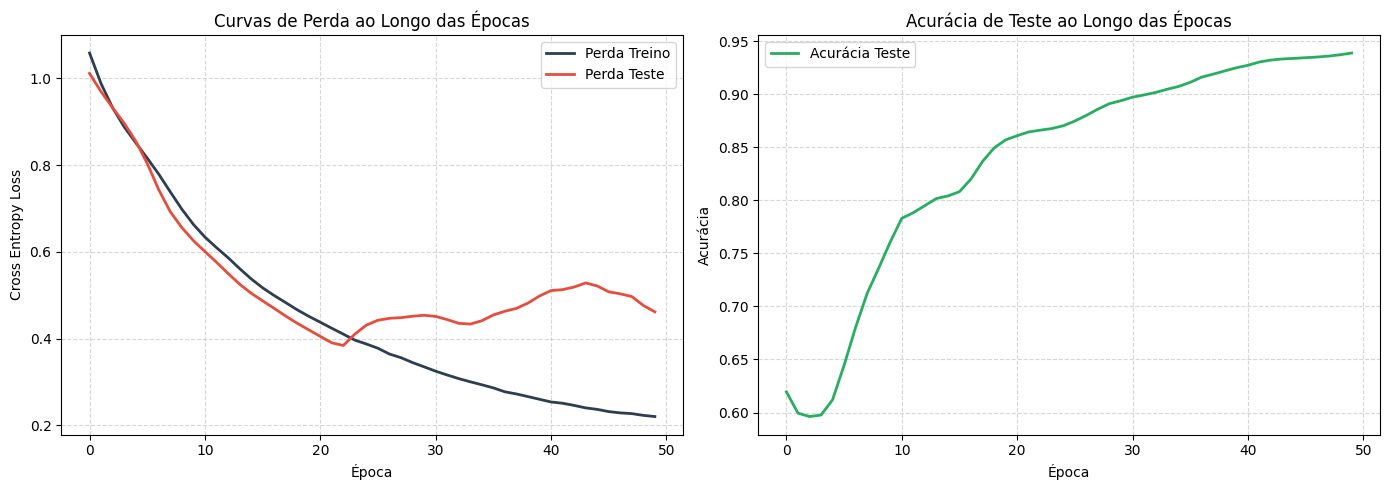


Relatório de Classificação Final:
              precision    recall  f1-score   support

      GALAXY       0.95      0.95      0.95     11889
         QSO       0.95      0.90      0.92      3792
        STAR       0.91      0.94      0.92      4319

    accuracy                           0.94     20000
   macro avg       0.94      0.93      0.93     20000
weighted avg       0.94      0.94      0.94     20000



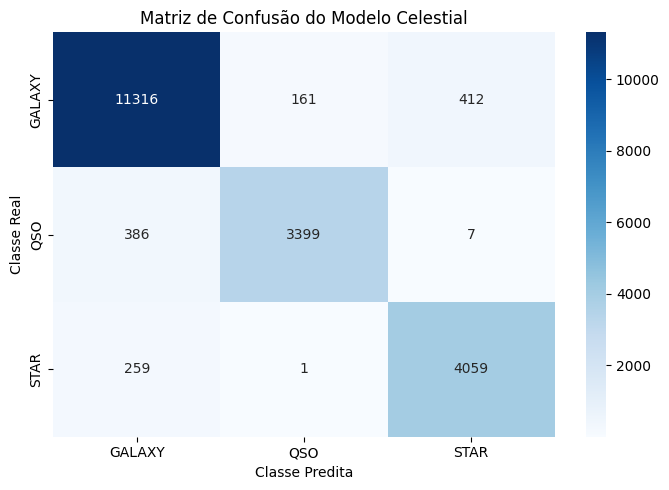

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de Perda
ax[0].plot(hist_perda_treino, label="Perda Treino", color="#2c3e50", lw=2)
ax[0].plot(hist_perda_teste, label="Perda Teste", color="#e74c3c", lw=2)
ax[0].set_title("Curvas de Perda ao Longo das Épocas")
ax[0].set_xlabel("Época")
ax[0].set_ylabel("Cross Entropy Loss")
ax[0].legend()
ax[0].grid(True, linestyle="--", alpha=0.5)

# Curva de Acurácia de Teste
ax[1].plot(hist_acuracia_teste, label="Acurácia Teste", color="#27ae60", lw=2)
ax[1].set_title("Acurácia de Teste ao Longo das Épocas")
ax[1].set_xlabel("Época")
ax[1].set_ylabel("Acurácia")
ax[1].legend()
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Avaliação final no conjunto de testes
modelo_treinado.eval()
with torch.no_grad():
    entradas_teste = torch.tensor(X_teste, dtype=torch.float32)
    saidas_teste = modelo_treinado(entradas_teste)
    _, predicoes_teste = torch.max(saidas_teste, 1)
    
predicoes_teste = predicoes_teste.numpy()

# Exibição do relatório técnico de classificação
print("\nRelatório de Classificação Final:")
nomes_classes = list(codificador.classes_)
print(classification_report(y_teste, predicoes_teste, target_names=nomes_classes))

# Matriz de Confusão
matriz_confusao = confusion_matrix(y_teste, predicoes_teste)
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_confusao, annot=True, fmt="d", cmap="Blues", xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title("Matriz de Confusão do Modelo Celestial")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.tight_layout()
plt.show()